In [2]:
import chipwhisperer as cw
scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial) #cw.targets.SimpleSerial can be omitted
scope.default_setup()
scope.adc.samples = 10000
scope.clock.adc_mul = 8

scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen                   
scope.glitch.phase_shift_steps           changed from 0                         to 4592                     
scope.trace.capture

In [4]:
%%bash
cd ../firmware/mcu/simpleserial-masked-nttmul/
make PLATFORM=CW308_STM32F3 CRYPTO_TARGET=NONE

Building for platform CW308_STM32F3 with CRYPTO_TARGET=NONE
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (Arm GNU Toolchain 15.2.Rel1 (Build arm-15.86)) 15.2.1 20251203
Copyright (C) 2025 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CW308_STM32F3 
.
Compiling:
-en     simpleserial-masked-nttmul.c ...
-e Done!
.
Compiling:
-en     .././simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     .././hal/hal.c ...
-e Done!
.
Compiling:
-en     .././hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     .././hal//stm32f3/stm32f3_hal_lowlevel.c ...
-e Done!
.
Compiling:
-en     .././hal//stm32f3/stm32f3_sysmem.c ...
-e Done!
.
Assembling: .././hal//stm32f3/stm32f3_startup.S
arm-none-eabi-gcc -c -mcpu=cortex-m4 -I. -x assembler-with-cpp -mthumb -mfloa

/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: warning: simpleserial-masked-nttmul-CW308_STM32F3.elf has a LOAD segment with RWX permissions


Memory region         Used Size  Region Size  %age Used
             RAM:        1688 B        40 KB      4.12%
             ROM:        5812 B       256 KB      2.22%
-e Done!
.
Creating load file for Flash: simpleserial-masked-nttmul-CW308_STM32F3.hex
arm-none-eabi-objcopy -O ihex -R .eeprom -R .fuse -R .lock -R .signature simpleserial-masked-nttmul-CW308_STM32F3.elf simpleserial-masked-nttmul-CW308_STM32F3.hex
.
Creating load file for Flash: simpleserial-masked-nttmul-CW308_STM32F3.bin
arm-none-eabi-objcopy -O binary -R .eeprom -R .fuse -R .lock -R .signature simpleserial-masked-nttmul-CW308_STM32F3.elf simpleserial-masked-nttmul-CW308_STM32F3.bin
.
Creating load file for EEPROM: simpleserial-masked-nttmul-CW308_STM32F3.eep
arm-none-eabi-objcopy -j .eeprom --set-section-flags=.eeprom="alloc,load" \
	--change-section-lma .eeprom=0 --no-change-warnings -O ihex simpleserial-masked-nttmul-CW308_STM32F3.elf simpleserial-masked-nttmul-CW308_STM32F3.eep || exit 0
.
Creating Extended Listin

In [12]:
cw.program_target(scope, cw.programmers.STM32FProgrammer, 
                  "../firmware/mcu/simpleserial-masked-nttmul/simpleserial-aes-CW308_STM32F3.hex")

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 5811 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 5811 bytes


In [14]:
import numpy as np
from tqdm import tqdm
np.random.seed(0)

KEBER_Q = 3329

secret = np.random.randint(0, 3329)
s0 = (secret >> 0) & 0xFF
s1 = (secret >> 8) & 0xFF

data = [0] * 12

rand_len = 8
np.random.randint(0, 3329, rand_len)

for i in tqdm(range(1)):
    data = [0] * 28
    
    s0_0 = np.random.randint(0, 3329)
    s0_1 = (s0 - s0_0) % KEBER_Q
    s1_0 = np.random.randint(0, 3329)
    s1_1 = (s1 - s1_0) % KEBER_Q

    data[0] = (s0_0 >> 0) & 0xFF
    data[1] = (s0_0 >> 8) & 0xFF
    data[2] = (s0_1 >> 0) & 0xFF
    data[3] = (s0_1 >> 8) & 0xFF

    data[4] = (s1_0 >> 0) & 0xFF
    data[5] = (s1_0 >> 8) & 0xFF
    data[6] = (s1_1 >> 0) & 0xFF
    data[7] = (s1_1 >> 8) & 0xFF
    
    b0 = np.random.randint(0, 3329)
    data[8] = (b0 >> 0) & 0xFF
    data[9] = (b0 >> 8) & 0xFF
    b1 = np.random.randint(0, 3329)
    data[10] = (b1 >> 0) & 0xFF
    data[11] = (b1 >> 8) & 0xFF

    for j in range(8):
        r_j = np.random.randint(0, 3329)
        data[12 + 2*j] = (r_j >> 0) & 0xFF
        data[12 + 2*j + 1] = (r_j >> 8) & 0xFF
        
    msg = bytearray(data)    
    scope.arm()
    #target.simpleserial_write('t', msg)
    #target.simpleserial_write('b', msg)
    target.simpleserial_write('p', msg[:8])
    scope.capture()
    #res = target.simpleserial_read('r', 8)
    res = target.simpleserial_read('r', 4)
    trace1 = scope.get_last_trace(as_int=True) # int16

    nparr_res = np.array(res).astype(np.int16)
    nparr_msg = np.array(msg).astype(np.int16)

print(res)
print(msg)

100%|██████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 39.77it/s]

bytearray(b'?\xfc\xe1\xfa')
bytearray(b"\xf2\x06\xbb\x06$\x07\xe7\x05W\nF\x0cX\n:\t\xc1\x02\'\nW\x08\xae\x08Q\x0b\xa5\x06")


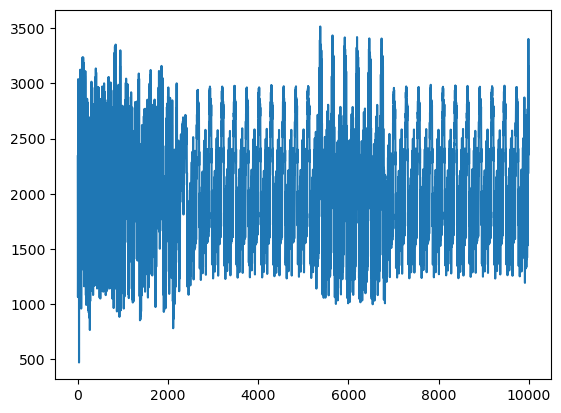

In [64]:
import matplotlib.pyplot as plt

plt.plot(trace1[:10000])


In [8]:
import numpy as np
from tqdm import tqdm
np.random.seed(0)

KEBER_Q = 3329

secret = np.random.randint(0, 3329)
s0 = (secret >> 0) & 0xFF
s1 = (secret >> 8) & 0xFF

data = [0] * 12

N = 10
rand_len = 8
np.random.randint(0, 3329, rand_len)

for i in tqdm(range(N)):
    data = [0] * 28
    
    s0_0 = np.random.randint(0, 3329)
    s0_1 = (s0 - s0_0) % KEBER_Q
    s1_0 = np.random.randint(0, 3329)
    s1_1 = (s1 - s1_0) % KEBER_Q

    data[0] = (s0_0 >> 0) & 0xFF
    data[1] = (s0_0 >> 8) & 0xFF
    data[2] = (s0_1 >> 0) & 0xFF
    data[3] = (s0_1 >> 8) & 0xFF

    data[4] = (s1_0 >> 0) & 0xFF
    data[5] = (s1_0 >> 8) & 0xFF
    data[6] = (s1_1 >> 0) & 0xFF
    data[7] = (s1_1 >> 8) & 0xFF
    
    b0 = np.random.randint(0, 3329)
    data[8] = (b0 >> 0) & 0xFF
    data[9] = (b0 >> 8) & 0xFF
    b1 = np.random.randint(0, 3329)
    data[10] = (b1 >> 0) & 0xFF
    data[11] = (b1 >> 8) & 0xFF

    for j in range(8):
        r_j = np.random.randint(0, 3329)
        data[12 + 2*j] = (r_j >> 0) & 0xFF
        data[12 + 2*j + 1] = (r_j >> 8) & 0xFF
        
    msg = bytearray(data)    
    scope.arm()
    target.simpleserial_write('t', msg)
    scope.capture()
    res = target.simpleserial_read('r', 8)
    trace = scope.get_last_trace(as_int=True) # int16

    nparr_res = np.array(res).astype(np.int16)
    nparr_msg = np.array(msg).astype(np.int16)
    #np.save(f"./trace_masked_mul/data_{i:04}.npy", np.concatenate([nparr_res, nparr_msg]))
    #np.save(f"./trace_masked_mul/trace_{i:04}.npy", trace)


100%|████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 23.15it/s]


In [10]:
QINV = 62209
KYBER_Q = 3329

def get_int16(t, lsb_idx):
    return int.from_bytes([t[lsb_idx], t[lsb_idx+1]], byteorder='little', signed=True)

def montgomery_reduce(a: int) -> int:
    a16 = np.int16(a & 0xFFFF) if a < 0 else np.int16(a % 2**16)
    t16 = np.int16(np.int32(a16) * QINV)
    u = np.int32(a) - np.int32(t16) * KYBER_Q
    return int(u >> 16)

def smlad(a_lo, a_hi, b_lo, b_hi):
    return int(np.int32(a_lo) * b_lo + np.int32(a_hi) * b_hi)

def smlsd(a_lo, a_hi, b_lo, b_hi):
    return int(np.int32(a_lo) * b_lo - np.int32(a_hi) * b_hi)



In [34]:
import numpy as np
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)
DEBUG = False
N = 500000

print(f"DEBUG? {'Yes' if DEBUG else 'No'}")

s0 = np.random.randint(0, 3329)
s1 = np.random.randint(0, 3329)

for i in tqdm(range(N)):

    # s = s0_0 + s0_1 mod q
    s0_0 = np.random.randint(0, 3329)
    s0_1 = (s0 - s0_0) % KYBER_Q
    s1_0 = np.random.randint(0, 3329)
    s1_1 = (s1 - s1_0) % KYBER_Q

    b0 = np.random.randint(0, KYBER_Q)
    b1 = np.random.randint(0, KYBER_Q)

    rand = np.random.randint(0, KYBER_Q, 8)

    def store16(x):
        return [x & 0xFF, (x >> 8) & 0xFF]

    packed = []
    packed += store16(s0_0)
    packed += store16(s0_1)
    packed += store16(s1_0)
    packed += store16(s1_1)
    packed += store16(b0)
    packed += store16(b1)
    for r in rand:
        packed += store16(r)

    msg = bytearray(packed)

    scope.arm()
    target.simpleserial_write('t', msg)
    scope.capture()
    res = target.simpleserial_read('r', 8)
    trace = scope.get_last_trace(as_int=True)  # obtain as int16 value

    nparr_res = np.array(res).astype(np.int16)
    nparr_msg = np.array(msg).astype(np.int16)

    np.savez(f"./trace_masked_pairwise_mul/sample_{i:08}.npz", 
             trace=trace, 
             meta=np.concatenate([nparr_res, nparr_msg]) )
    
    if DEBUG:
        packed = []
        packed += store16((s0_0 + s0_1) % KYBER_Q)
        packed += store16((s1_0 + s1_1) % KYBER_Q)
        packed += store16(b0)
        packed += store16(b1)
    
        msg2 = bytearray(packed)
        target.simpleserial_write('p', msg2)
        res2 = target.simpleserial_read('r', 4)
    
        
        vals = [get_int16(msg, i*2) for i in range(14)]
        s0_0, s0_1, s1_0, s1_1, b0, b1 = vals[:6]
        r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]
        
        zeta = np.int16(-1044) 
        b_zeta = montgomery_reduce(np.int32(zeta) * b1)
        
        acc0 = smlad(s0_0, r0, b0, r1) + smlad(s1_0, r2, b_zeta, r3)
        acc1 = smlad(s0_1, -r0, b0, r1) + smlad(s1_1, -r2, b_zeta, r3)
        #acc_sum1 = acc0 + acc1
        #sum_simulated1 = montgomery_reduce(acc_sum1)
            
        acc2 = smlad(s0_0, r4, b1, r5) + smlad(s1_0, r6, b0, r7)
        acc3 = smlad(s0_1, -r4, b1, r5) + smlad(s1_1, -r6, b0, r7)
        #acc_sum = acc2 + acc3
        #sum_simulated = montgomery_reduce(acc_sum)
    
        assert( montgomery_reduce(acc0) == get_int16(res, 0) )
        assert( montgomery_reduce(acc1) == get_int16(res, 2) )
        assert( montgomery_reduce(acc2) == get_int16(res, 4) )
        assert( montgomery_reduce(acc3) == get_int16(res, 6) )


DEBUG? No


100%|██████████████████████████████████████████████████████| 500000/500000 [5:17:12<00:00, 26.27it/s]


In [36]:
scope.dis()
target.dis()

In [38]:
from tqdm import tqdm
import numpy as np

import warnings
warnings.filterwarnings('ignore')

for i in tqdm(range(N)):
    sample = np.load(f"./trace_masked_pairwise_mul/sample_{i:08}.npz")
    trace = sample["trace"]
    data = sample["meta"]
    
    res = data[:8]
    msg = data[8:]
    
    vals = [get_int16(msg, i*2) for i in range(14)]
    s0_0, s0_1, s1_0, s1_1, b0, b1 = vals[:6]
    r0, r1, r2, r3, r4, r5, r6, r7 = vals[6:]

    
    zeta = np.int16(-1044) 
    b_zeta = montgomery_reduce(np.int32(zeta) * b1)
    
    acc0 = smlad(s0_0, r0, b0, r1) + smlad(s1_0, r2, b_zeta, r3)
    acc1 = smlad(s0_1, -r0, b0, r1) + smlad(s1_1, -r2, b_zeta, r3)
    acc_sum1 = acc0 + acc1
    sum_simulated1 = montgomery_reduce(acc_sum1)
        
    acc2 = smlad(s0_0, r4, b1, r5) + smlad(s1_0, r6, b0, r7)
    acc3 = smlad(s0_1, -r4, b1, r5) + smlad(s1_1, -r6, b0, r7)
    acc_sum = acc2 + acc3
    sum_simulated = montgomery_reduce(acc_sum)

    assert( montgomery_reduce(acc0) == get_int16(res, 0) )
    assert( montgomery_reduce(acc1) == get_int16(res, 2) )
    assert( montgomery_reduce(acc2) == get_int16(res, 4) )
    assert( montgomery_reduce(acc3) == get_int16(res, 6) )

100%|██████████████████████████████████████████████████████| 500000/500000 [02:44<00:00, 3040.53it/s]
